# **Parte 1: Estadística Inferencial**

El Global Findex es una base de datos del Banco Mundial que mide cómo las personas de distintos países usan servicios financieros como cuentas, créditos, ahorros y pagos digitales.

Esta semana estaremos trabajando con un dataset que contiene la información del Global Findex de los últimos años. El objetivo es comprender cómo se utilizan distintos servicios financieros alrededor del mundo y del tiempo. Comenzaremos por analizar la variable **fiaccount_t_d**, que mide el porcentaje de personas que respondieron la encuesta que reportar tener una cuenta bancaria en un banco o institución financiera.

### **Teorema Central del Límite**

1. Tomar 200 muestras de 500 valores cada una, y almacenar la media de cada muestra en una lista.
2. Calcular la media y la varianza de las medias muestrales.
3. Comparar el resultado con la media poblacional.

In [8]:
import numpy as np
import numpy.random as rnd
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
# Replace '/content/drive/MyDrive/your_folder/GlobalFindexDatabase2025.csv' with the actual path to your file in Google Drive
df = pd.read_csv('/content/GlobalFindexDatabase2025.csv')
def plot_sample_dist(n):
    m = df['fiaccount_t_d'].mean()
    s = df['fiaccount_t_d'].std() / np.sqrt(n)
    x = np.linspace(m - 3 * s, m + 3 * s, 100)
    norm = sp.stats.norm(m, s)
    plt.plot(x, norm.pdf(x), "k--", alpha=0.5)
    sns.histplot([df['fiaccount_t_d'].sample(n, replace=True, random_state=i ).mean() for i in range(200)], kde=True, stat="density")
plot_sample_dist(500)

ModuleNotFoundError: No module named 'numpy'

<Axes: ylabel='Density'>

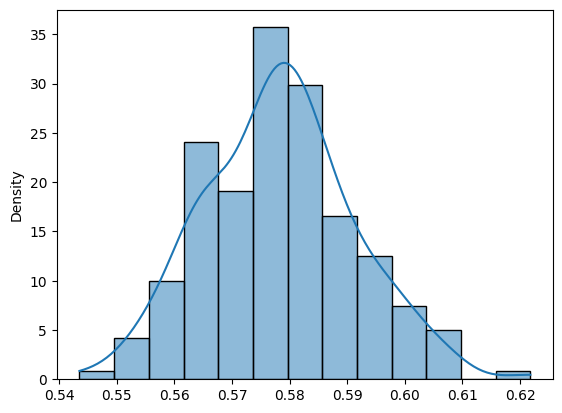

In [ ]:
pop = df.fiaccount_t_d
n = 500
k = 200
avg_sample = pd.Series([float(pop.sample(n, random_state=i ).mean() )for i in range(k)])
sns.histplot(avg_sample,kde = True, stat = "density")


In [ ]:
display(pop.mean())
display(pop.var())
display(avg_sample.mean())
display(avg_sample.var())
pop.var() / avg_sample.var()

np.float64(0.5782029059914122)

0.09025287155994927

np.float64(0.5782137059788612)

0.0001665137635352954

542.0144836304697

### **Intervalos de Confianza**

Supongamos que como son estudiantes, el Banco Mundial ha decidido limitar el acceso a toda la información. Cada uno podrá acceder a una muestra aleatoria de 1000 filas.

1. Obtener la muestra aleatoria con la que estarás trabajando en esta clase.


```
df_sample = df.sample(1000)
```

**Importante!!!** Cada vez que vuelvas a correr esta celda, cambiarán los datos que se incluyen en tu muestra.

2. Calcular el intervalo de confianza para la media con un nivel de confianza de 0,05, utilizando el desvío poblacional que pueden obtener a partir del dataset completo.

3. Ahora supongamos que no pueden acceder al dataset completo. Calcular el intervalo de confianza para la media con un nivel de confianza de 0,05, utilizando el desvío muestral.

In [ ]:
n =1000
df_sample = df['fiaccount_t_d'].sample(n)

xRaya = df_sample.mean()
z = sp.stats.norm.ppf(0.05/2)
S = df_sample.std()
limI = xRaya - (z * pop.std()/ np.sqrt(n))
limS = xRaya + (z * pop.std()/ np.sqrt(n))
IC = [float(limI),float(limS)]
IC

NameError: name 'df' is not defined

### **Test de Hipótesis**

Dos políticos que trabajan en el Banco Mundial están debatiendo acerca de la media poblacional para la variable que estamos analizando. Uno dice que debe ser aproximadamente 0,5, mientras que el otro afirma que se encuentra por encima de 0,55.

Utilizando la misma muestra que en el punto anterior,

1. Realizar un test de hipótesis para *H0: Media = 0,5*, con un nivel de confianza de 0,1.

*   ¿Es posible rechazar la hipótesis?
*   ¿Cuál es la probabilidad de error tipo I?
*   ¿Cuál es la probabilidad de error tipo II?

2. Realizar un test de hipótesis para *H0: Media > 0,55*, con un nivel de confianza de 0,1.

*   ¿Es posible rechazar la hipótesis?
*   ¿Cuál es la probabilidad de error tipo I?
*   ¿Cuál es la probabilidad de error tipo II?


In [ ]:
h0 = 0.5
t = (xRaya - h0)/ ()

test de hipotesis (H0: Media = 0.5):
X raya: 0.5801766316731357
T-statistic: 8.444395736877954
P-valor: 2.220446049250313e-16
REchazamos H0 con un riezgo = 0.1
Probabilidad de un error tipo 1: 0.1

Test de hipotesis 2 (H0: media > 0.55):
X raya: 0.5801766316731357
T-statistic: 3.178275446801355
P-valor: 0.0007635276934686575
Reject H0 at alpha = 0.1
Probability of Type I error: 0.1
